In [ ]:
import pandas as pd
import os
import pyranges as pr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def get_hotspot_overlap(vcf_df, bed_df, mutation_type = 'substitution'):

    alises = {'CHROM':'Chromosome', 'Stop':'End'}
    
    if mutation_type == 'substitution':
        bed_df = bed_df.copy()
        bed_df.columns = [alises[i] if i in alises.keys() else i for i in bed_df.columns]

        vcf_df = vcf_df.copy()
        vcf_df.columns = ['Chromosome', 'Start', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']
        vcf_df['End'] = vcf_df['Start']
    elif mutation_type == 'CNA':
        bed_df = bed_df.copy()
        bed_df.columns = [alises[i] if i in alises.keys() else i for i in bed_df.columns]

        vcf_df = vcf_df.copy()    
    else:
        print('finish the function')

    # Create PyRanges objects from BED and VCF DataFrames
    bed_pr = pr.PyRanges(bed_df)
    vcf_pr = pr.PyRanges(vcf_df)

    # Find overlaps
    overlaps = bed_pr.join(vcf_pr)

    # Convert back to a DataFrame if needed
    overlaps_df = overlaps.df
    
    
    if mutation_type == 'substitution':
        # reformat:
        del(overlaps_df['End_b'])
        overlaps_df = overlaps_df.rename(columns={'Start_b':'pos'})    
        overlaps_df['variant_id'] = overlaps_df['Chromosome'].astype(str)+':'+overlaps_df['pos'].astype(str)+':'+overlaps_df['ALT']
    
    return overlaps_df

sex_assignment = {
    'PD63564': 'XX',
    'PD60967': 'XY',
    'PD60966': 'XY'
}

In [ ]:
donor = 'PD60967'

In [ ]:
wd = '../data/LCM_analysis/'
os.makedirs(wd+'pyclone_vi', exist_ok=True)

In [ ]:
# only keep variants where at least one normal sample passes
# format to pyclone
# consider filtering CN regions
# estimate tumour purity - VAF method

shearwater_df = pd.read_csv(wd+'shearwater_output/{}/{}_shearwater_pval_mat.txt'.format(donor,donor), sep = ' ')

cgpVAF_file = [f for f in os.listdir(wd+'cgpVAF_snps') if donor in f and f.endswith(".tsv")]
line_count = sum(1 for line in open(wd+'cgpVAF_snps/'+cgpVAF_file[0]) if line.startswith("#"))
cgpVAF_df = pd.read_csv(wd+'cgpVAF_snps/'+cgpVAF_file[0], skiprows = line_count-1, sep="\t")
cgpVAF_df['ID'] = cgpVAF_df['Chrom'].astype(str)+'_'+cgpVAF_df['Pos'].astype(str)

LCM_files = [i for i in shearwater_df.columns if donor in i]

In [ ]:
# filter variants in which none pass shearwater filters
shearwater_df = shearwater_df[LCM_files]
shearwater_df = shearwater_df[(shearwater_df < 0.001).any(axis=1)]

cgpVAF_df = cgpVAF_df[cgpVAF_df['ID'].isin(shearwater_df.index.tolist())]

In [ ]:
# remove CNV regions; use batternberg summary for this
# merge all coordinates then filter

# Load CNAs 
columns = ['Segment number', 'Chromosome', 'Start', 'End', 
           'normal_CN', 'normal_min_allele_CN', 'tumour_CN', 'tumour_min_allele_CN']
large_CNs = []
for sample in LCM_files:
    file = wd+'symlinks/{}.ascat_ngs.summary.csv'.format(sample)
    if os.path.exists(file):
        large_CNs.append(
            pd.read_csv(file, 
                        header=None, 
                        names = columns).drop('Segment number', axis=1)
        )
large_CNs = pd.concat(large_CNs)
large_CNs = large_CNs[large_CNs['normal_CN']!=large_CNs['tumour_CN']].drop_duplicates()

overlap_hotspots = get_hotspot_overlap(cgpVAF_df[['Chrom', 'Pos', 'ID', 'Ref', 'Alt', 
                                                           'Qual', 'Filter', 'Gene']], 
                                       large_CNs)
overlap_hotspots['ID_tmp'] = overlap_hotspots[['Chromosome', 'pos', 'REF', 'ALT']]\
                        .apply(lambda row: '_'.join(row.values.astype(str)), axis=1)
overlapping_variants = list(set(overlap_hotspots['ID_tmp']))

cgpVAF_df['ID_tmp'] = cgpVAF_df[['Chrom', 'Pos', 'Ref', 'Alt']]\
                        .apply(lambda row: '_'.join(row.values.astype(str)), axis=1)
cgpVAF_df = cgpVAF_df[~cgpVAF_df['ID_tmp'].isin(overlap_hotspots['ID_tmp'])].drop('ID_tmp', axis=1)
    

# get overlap with variant/sample long form df and merge a concatenated version with sample-specific CNs
# could save as potentially useful metadata (might be requested);
# but filter ALL CN regions as some CNs are underrepresented in low purity samples and therefore will confound results

In [ ]:
# Format for pyclone-VI; 
# MTR and WTR are the mutant (M) and wild type (W) allele counts, respectively
# VAF is rounded but cleanly corresponds to the MTR percentage
cgpVAF_df['mutation_id'] = cgpVAF_df['Chrom']+':'+cgpVAF_df['Pos'].astype(str)+':'+cgpVAF_df['Ref']+':'+cgpVAF_df['Alt']
cgpVAF_df = cgpVAF_df.set_index('mutation_id')

columns = [[c for c in cgpVAF_df.columns if c==i+'_MTR' or c==i+'_WTR'] for i in LCM_files] # keep only allele count columns
columns = [i for l in columns for i in l]

allele_counts = cgpVAF_df[columns].reset_index().melt(var_name='full_col', value_name='value', id_vars='mutation_id')
allele_counts[['sample_id', 'allele_counts']] = allele_counts['full_col'].str.extract('(.+)_(\w+)$')
allele_counts = allele_counts.pivot(columns='allele_counts', index=['mutation_id', 'sample_id'], values='value').reset_index()


In [ ]:
# Estimate tumour purity through median VAFs
# essentially, median VAF / expected VAF ~ purity
# Remove homozygous alleles

# confirm battenberg with VAFs; DEPRECATED
allele_counts['VAF'] = allele_counts['MTR']/(allele_counts['MTR']+allele_counts['WTR'])
tumour_content_ratio = allele_counts[(allele_counts['VAF']!=0) & 
                               (allele_counts['VAF']!=1)].groupby('sample_id')['VAF'].median()\
                                .divide(0.5).reset_index()
tumour_content_ratio = tumour_content_ratio.rename(columns={'VAF':'tumour_content'})

# battenberg:
tumour_content = []
link_broken = []
for file in LCM_files:
    link = wd+'symlinks/{}.battenberg.cellularity_ploidy.txt'.format(file)
    if os.path.exists(link):
        df = pd.read_csv(link, sep = '\t')
        df['sample_id'] = file
        df = df.rename(columns={'cellularity':'tumour_content'})
        tumour_content.append(df[['sample_id', 'tumour_content']])
    else:
        link_broken.append(file)
        print('Resorting to ratio for {}...'.format(file))
        df = tumour_content_ratio[tumour_content_ratio['sample_id']==file]
        tumour_content.append(df[['sample_id', 'tumour_content']])

tumour_content = pd.concat(tumour_content, ignore_index=True)


Resorting to ratio for PD60967a_lo0013...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


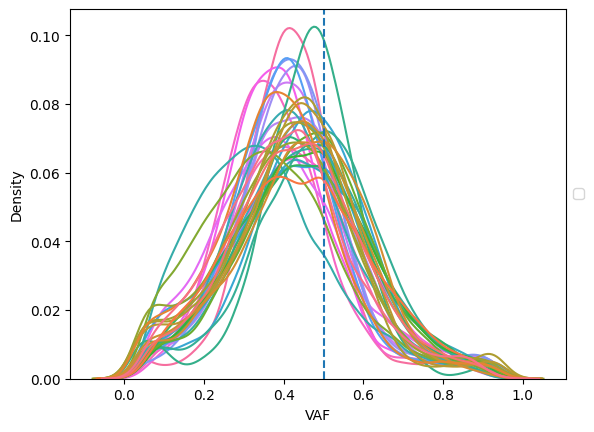

In [ ]:
# Check tumour purity and VAF distributions of non homozygous alleles

sns.kdeplot(data=allele_counts[(allele_counts['VAF']!=0) & (allele_counts['VAF']!=1)], 
            x="VAF", hue="sample_id", fill=False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.axvline(0.5, linestyle = '--')
plt.show()


In [ ]:
ps = allele_counts[(allele_counts['VAF']!=0) &
                   (allele_counts['VAF']!=1) & 
                   (allele_counts['sample_id']==allele_counts.groupby('sample_id')['VAF'].median().idxmin())]

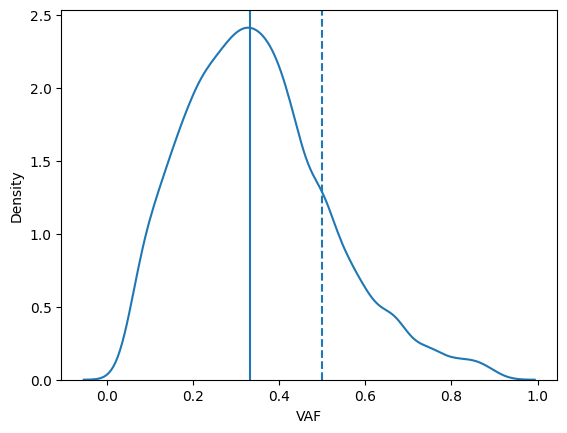

In [ ]:
sns.kdeplot(data=ps, 
            x="VAF", fill=False)
plt.axvline(0.5, linestyle = '--')
plt.axvline(ps['VAF'].median())
plt.show()


In [ ]:
if 'tumour_content' not in allele_counts.columns:
    allele_counts = allele_counts.merge(tumour_content.reset_index(), on = 'sample_id')

In [ ]:
# Coerced to default expectations given previous CN filter
allele_counts['major_cn'] = 1
allele_counts['minor_cn'] = 1
allele_counts['normal_cn'] = 2

# make assignment very explicit for posterity
if sex_assignment[donor] == 'XY':
    # X chromosome
    allele_counts['minor_cn'] = np.where(allele_counts['mutation_id'].str.contains('chrY'), 0, allele_counts['minor_cn'])
    allele_counts['normal_cn'] = np.where(allele_counts['mutation_id'].str.contains('chrY'), 1, allele_counts['normal_cn'])
    # Y chromosome
    allele_counts['minor_cn'] = np.where(allele_counts['mutation_id'].str.contains('chrX'), 0, allele_counts['minor_cn'])
    allele_counts['normal_cn'] = np.where(allele_counts['mutation_id'].str.contains('chrX'), 1, allele_counts['normal_cn'])


# rename cgpVAF columns
allele_counts = allele_counts.rename(columns={'MTR':'alt_counts', 'WTR':'ref_counts'})

In [ ]:
allele_counts[['mutation_id', 'sample_id', 'ref_counts', 'alt_counts',
               'major_cn', 'minor_cn', 'normal_cn', 'tumour_content']]\
    .to_csv(wd+'pyclone_vi/{}_input.tsv'.format(donor), sep = '\t', index=None)

In [ ]:
# ach patient was run with the following non-default parameters: 
# # number of grid points = 150, number of restarts = 100, number of maximum expected clusters = 30.
input_file = wd+'pyclone_vi/{}_input.tsv'.format(donor)
output_file = wd+'pyclone_vi/{}_output.h5'.format(donor)

!pyclone-vi fit -i {input_file} -o {output_file} -c 30 -d beta-binomial -r 100 -g 150

output_table = wd+'pyclone_vi/{}_output.tsv'.format(donor)

!pyclone-vi write-results-file -i {output_file} -o {output_table}


Num Samples: 35
Samples: PD60967a_lo0003 PD60967a_lo0004 PD60967a_lo0005 PD60967a_lo0009 PD60967a_lo0013 PD60967a_lo0014 PD60967a_lo0015 PD60967a_lo0019 PD60967a_lo0020 PD60967a_lo0022...
Num mutations: 5403
Performing restart 0
Setting annealing factor to : 1.0

Iteration: 0
ELBO: -2509466.9109544205
Number of clusters used: 30

Fitting completed
ELBO: -379685.02297376853
Number of clusters used: 5

Performing restart 1
Setting annealing factor to : 1.0

Iteration: 0
ELBO: -2330466.2379374825
Number of clusters used: 30

Fitting completed
ELBO: -374112.624643436
Number of clusters used: 7

Performing restart 2
Setting annealing factor to : 1.0

Iteration: 0
ELBO: -5210184.388185326
Number of clusters used: 30

Fitting completed
ELBO: -377472.9206736921
Number of clusters used: 7

Performing restart 3
Setting annealing factor to : 1.0

Iteration: 0
ELBO: -1575675.1423282402
Number of clusters used: 30

Iteration: 100
ELBO: -373554.45912389754
Number of clusters used: 9

Fitting comple